# Why Do Some Restaurants Fail on Zomato Bangalore?
## A Data analysis for Food-Tech Business Strategy

**Problem Statement:**
While Zomato offers equal visibility to all listed restaurants in Bangalore,
some consistently receive high ratings and customer engagement while others
struggle to survive. This analysis investigates what factors — cuisine type,
location, price range, and service features — differentiate successful
restaurants from failing ones.

**Key Questions:**
1. Which cuisines and localities have the highest average ratings?
2. Does price range affect customer ratings and votes?
3. Do online ordering and table booking options impact restaurant success?

**Tools Used:** Python, Pandas, Matplotlib, Seaborn
**Dataset:** Zomato Bangalore Restaurants — Kaggle (51,000+ rows)

## Data Loading

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
%matplotlib inline

In [55]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,5)

In [59]:
df = pd.read_csv('zomato.csv')

In [59]:
df.shape

(51717, 17)

In [61]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [65]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [67]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


## Data cleaning

In [70]:
cols_to_drop = ['url', 'address', 'phone', 'dish_liked', 
                'menu_item', 'reviews_list']

df = df.drop(columns=cols_to_drop)
print(f"Columns remaining: {df.shape[1]}")
print(df.columns.tolist())

Columns remaining: 11
['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']


These columns add no value to the above 3 business questions. So dropped 

In [73]:
# Check what unique messy values exist
print(df['rate'].unique()[:20])

['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' 'NEW' '2.9/5' '3.5/5' nan
 '2.6/5']


In [75]:
# Remove '/5' and convert to float
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False)
df['rate'] = df['rate'].str.strip()

# Replace non-numeric values with NaN
df['rate'] = df['rate'].replace(['NEW', '-', 'nan'], np.nan)

# Convert to float
df['rate'] = df['rate'].astype(float)

print(df['rate'].dtype)
print(df['rate'].describe())

float64
count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64


Most Bangalore restaurants cluster between 3.4 and 4.0, meaning a rating above 4.0 is a strong differentiator for success.

In [78]:
# Remove commas like "1,200" to "1200"
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '', regex=False)

# Convert to numeric
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

print(df['approx_cost(for two people)'].describe())

count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64


Bangalore's food market is largely budget-driven — 75% of restaurants cost ₹650 or less for two people, suggesting price sensitivity is high among Zomato users

In [81]:
df = df.dropna()
print(f"Clean dataset shape: {df.shape}")

Clean dataset shape: (41263, 11)


In [83]:
df = df.reset_index(drop=True)
print(f"Final shape: {df.shape}")
print(f"Null values remaining: {df.isnull().sum().sum()}")
df.head()

Final shape: (41263, 11)
Null values remaining: 0


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


## Exploratory Data Analysis

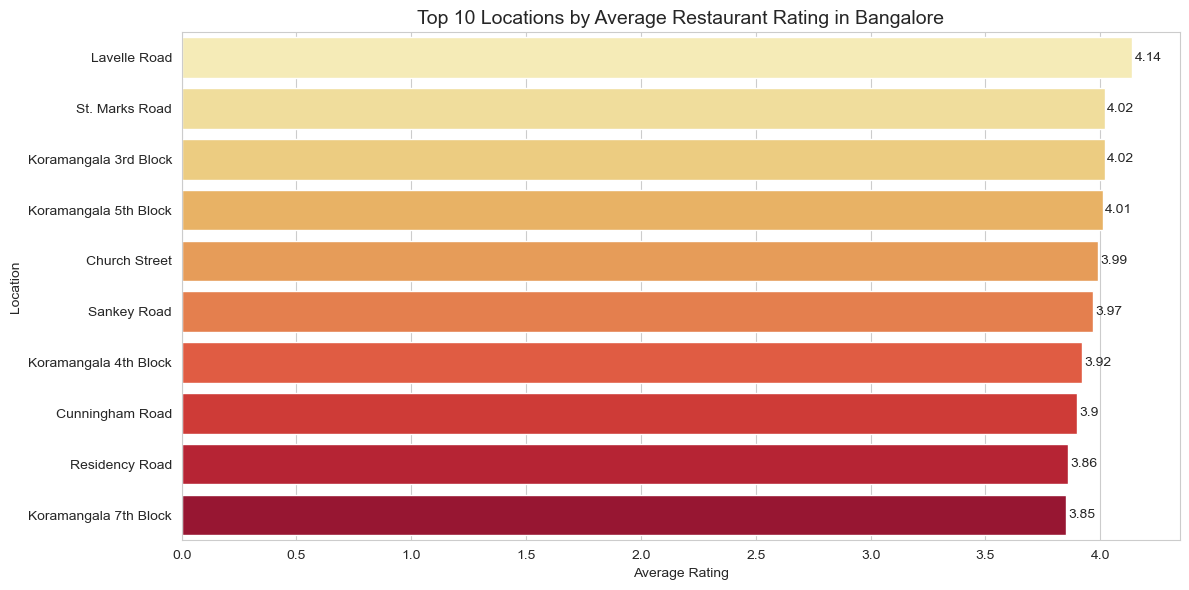

In [88]:
# Step 1 - Calculate average rating per location
location_rating = df.groupby('location')['rate'].mean().round(2)

# Step 2 - Sort and take top 10
location_rating = location_rating.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=location_rating.values, y=location_rating.index, 
            hue=location_rating.index, palette='YlOrRd', legend=False)
plt.title('Top 10 Locations by Average Restaurant Rating in Bangalore', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Location')

for i, v in enumerate(location_rating.values):
    plt.text(v + 0.01, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

Lavelle Road and St. Marks Road are Bangalore's highest rated dining zones, while Koramangala dominates with 3 blocks in the top 10 — suggesting it is the most consistently high-quality food neighbourhood on Zomato

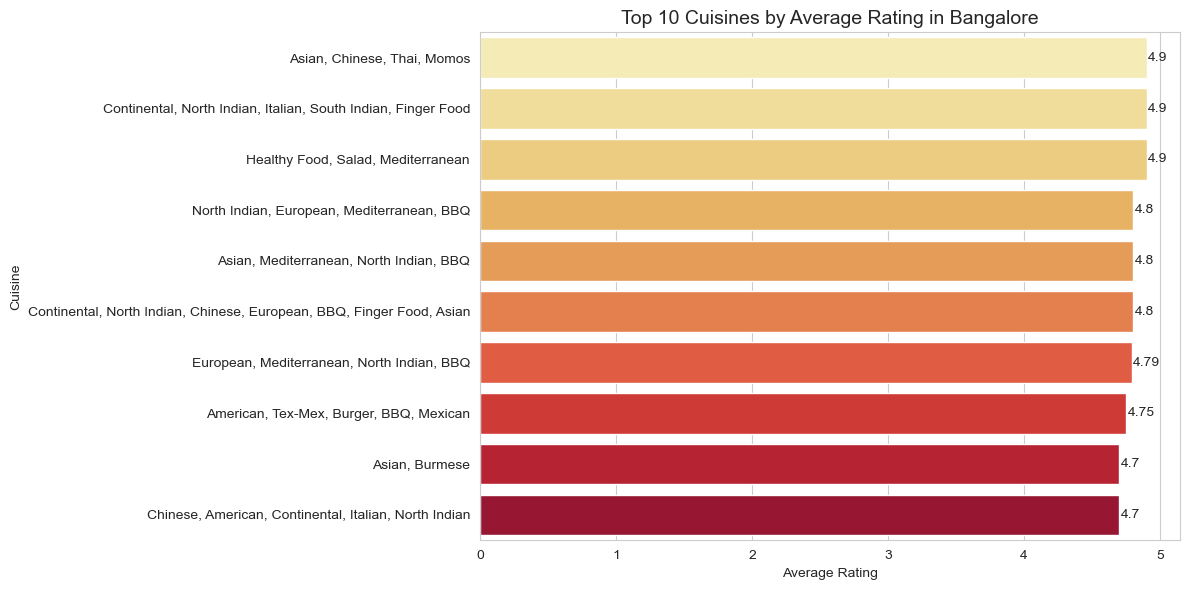

In [91]:
# Step 1 - Calculate average rating per cuisine
cuisine_rating = df.groupby('cuisines')['rate'].mean().round(2)

# Step 2 - Sort and take top 10
cuisine_rating = cuisine_rating.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index,
            hue=cuisine_rating.index, palette='YlOrRd', legend=False)

plt.title('Top 10 Cuisines by Average Rating in Bangalore', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')

for i, v in enumerate(cuisine_rating.values):
    plt.text(v + 0.01, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

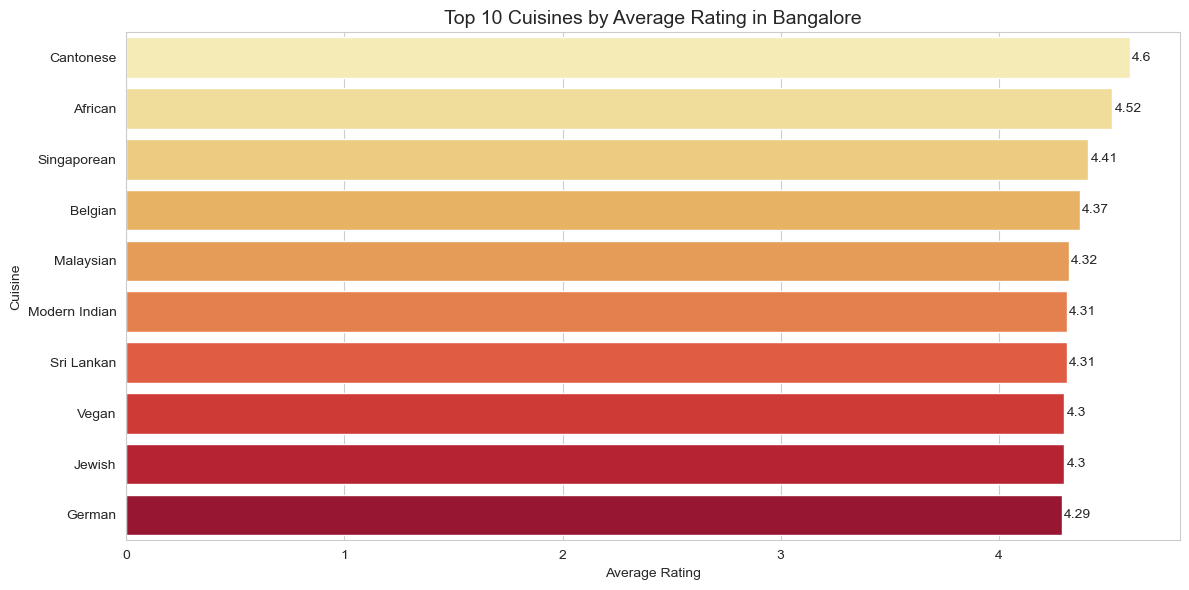

In [39]:
# Split combined cuisines and explode into individual rows
cuisine_split = df.assign(
    cuisines=df['cuisines'].str.split(',')
).explode('cuisines')

# Cleaning extra spaces
cuisine_split['cuisines'] = cuisine_split['cuisines'].str.strip()

# calculating average rating per single cuisine
cuisine_rating = cuisine_split.groupby('cuisines')['rate'].mean().round(2)

# Sorting and take top 10
cuisine_rating = cuisine_rating.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index,
            hue=cuisine_rating.index, palette='YlOrRd', legend=False)

plt.title('Top 10 Cuisines by Average Rating in Bangalore', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')

for i, v in enumerate(cuisine_rating.values):
    plt.text(v + 0.01, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()


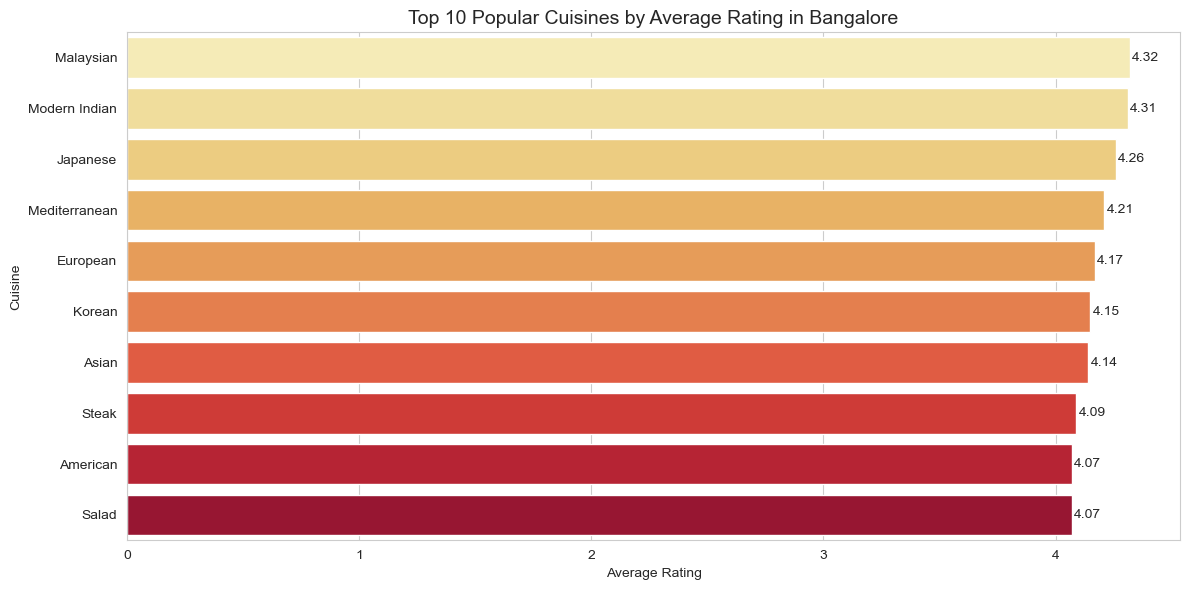

In [93]:
# Counting how many restaurants per cuisine
cuisine_counts = cuisine_split.groupby('cuisines')['rate'].count()

# Keeping only cuisines with at least 100 restaurants
popular_cuisines = cuisine_counts[cuisine_counts >= 100].index

# Filter to only popular cuisines
cuisine_filtered = cuisine_split[cuisine_split['cuisines'].isin(popular_cuisines)]

# calculating average rating
cuisine_rating = cuisine_filtered.groupby('cuisines')['rate'].mean().round(2)
cuisine_rating = cuisine_rating.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index,
            hue=cuisine_rating.index, palette='YlOrRd', legend=False)

plt.title('Top 10 Popular Cuisines by Average Rating in Bangalore', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')

for i, v in enumerate(cuisine_rating.values):
    plt.text(v + 0.01, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

International and fusion cuisines like Malaysian, Japanese and Mediterranean consistently outperform traditional Indian cuisines in customer ratings — suggesting Bangalore's Zomato users reward unique dining experiences over familiar food options.

In [96]:
# Creating price range categories
df['price_range'] = pd.cut(df['approx_cost(for two people)'],
                           bins=[0, 300, 600, 1000, 6000],
                           labels=['Budget (₹0-300)', 
                                   'Mid Range (₹301-600)', 
                                   'Premium (₹601-1000)', 
                                   'Luxury (₹1000+)'])


print(df['price_range'].value_counts())

price_range
Mid Range (₹301-600)    15820
Budget (₹0-300)         12535
Premium (₹601-1000)      7773
Luxury (₹1000+)          5135
Name: count, dtype: int64


68% of all restaurants are Budget or Mid Range — this confirms what we saw earlier from the median ₹400 finding.
Only 13% are Luxury — very small market on Zomato.

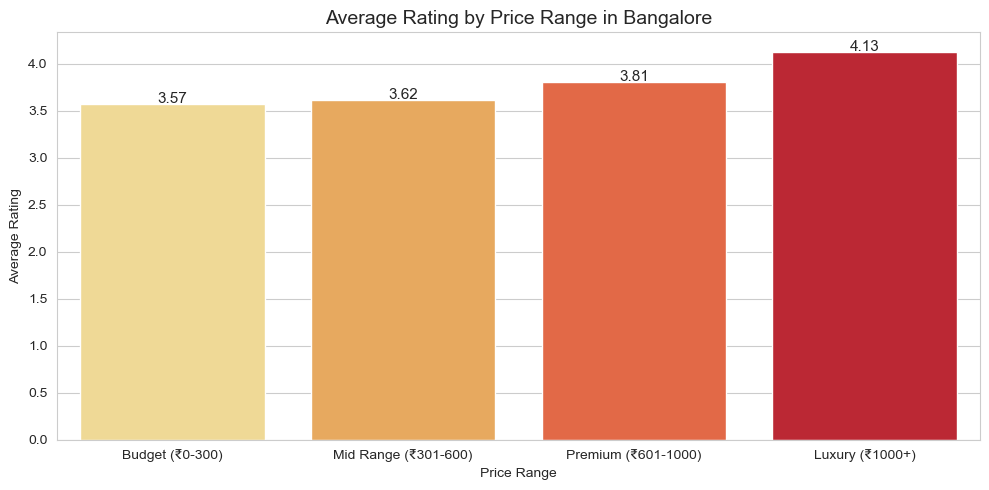

In [101]:
# Calculating average rating per price range
price_rating = df.groupby('price_range', observed=True)['rate'].mean().round(2)

plt.figure(figsize=(10, 5))
sns.barplot(x=price_rating.index, y=price_rating.values,
            hue=price_rating.index, palette='YlOrRd', legend=False)

plt.title('Average Rating by Price Range in Bangalore', fontsize=14)
plt.xlabel('Price Range')
plt.ylabel('Average Rating')

for i, v in enumerate(price_rating.values):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Higher priced restaurants consistently receive better ratings on Zomato Bangalore — Luxury restaurants (₹1000+) average 4.13 compared to 3.57 for Budget restaurants. However, 68% of restaurants are Budget or Mid Range, meaning most new entrants compete in a lower-rated, highly crowded segment

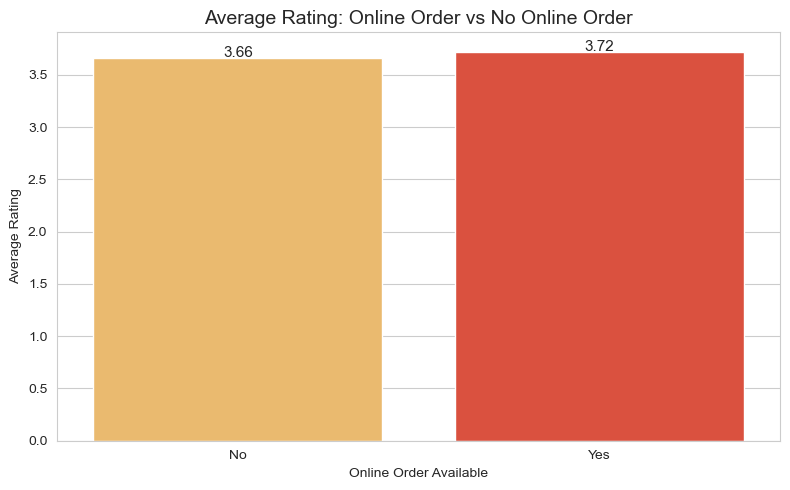

In [104]:
#  Online Order vs Average Rating
online_rating = df.groupby('online_order')['rate'].mean().round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=online_rating.index, y=online_rating.values,
            hue=online_rating.index, palette='YlOrRd', legend=False)

plt.title('Average Rating: Online Order vs No Online Order', fontsize=14)
plt.xlabel('Online Order Available')
plt.ylabel('Average Rating')

for i, v in enumerate(online_rating.values):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Restaurants offering online ordering score marginally higher ratings (3.72 vs 3.66) — while the gap is small, online ordering may increase customer touchpoints and engagement, making it a recommended feature for new restaurants entering the Zomato platform.

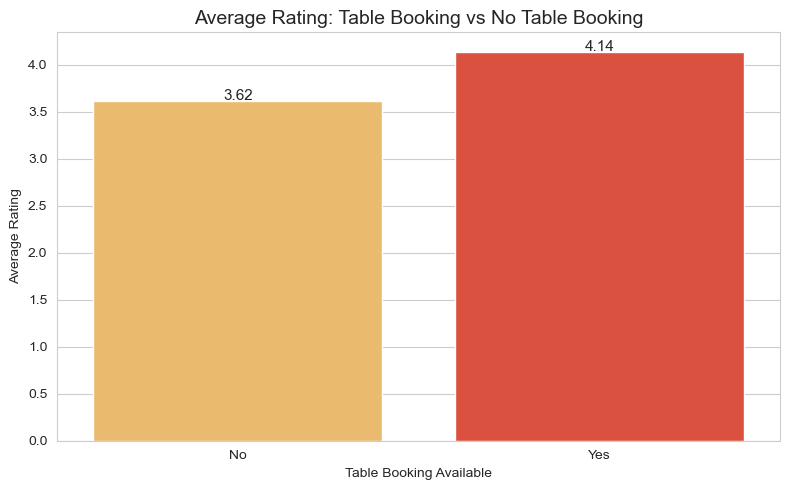

In [107]:
# Table Booking vs Average Rating
table_rating = df.groupby('book_table')['rate'].mean().round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=table_rating.index, y=table_rating.values,
            hue=table_rating.index, palette='YlOrRd', legend=False)

plt.title('Average Rating: Table Booking vs No Table Booking', fontsize=14)
plt.xlabel('Table Booking Available')
plt.ylabel('Average Rating')

for i, v in enumerate(table_rating.values):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Restaurants offering table booking score dramatically higher ratings (4.14 vs 3.62) — a gap of 0.52 points, the largest difference found in this analysis. Table booking signals a premium dining experience, and new restaurants targeting high ratings should consider investing in reservation systems alongside food quality.

## Key Insights & Business Recommendations

### What Makes a Restaurant Successful on Zomato Bangalore?

Based on the analysis of 41,263 restaurants across Bangalore,
five key factors were identified that separate high-performing
restaurants from struggling ones.

---

### Insight 1 — Location Matters, But Not as Much as You Think
**Finding:** Lavelle Road (4.14) and St. Marks Road (4.02) are
Bangalore's highest rated zones. Koramangala dominates with
3 blocks in the top 10.

**But:** The rating gap between rank 1 and rank 10 is only 0.29
points (4.14 vs 3.85) — meaning location alone cannot make or
break a restaurant.

**Recommendation:** New restaurants should target Koramangala
or Lavelle Road for visibility, but focus more on food quality
since location has limited impact on ratings.

---

### Insight 2 — International Cuisines Outperform Traditional Indian
**Finding:** Malaysian (4.32), Modern Indian (4.31) and Japanese
(4.26) are the highest rated popular cuisines. Traditional North
Indian and South Indian cuisines do not appear in the top 10.

**Recommendation:** New restaurants offering unique international
or fusion cuisine have a higher chance of standing out and receiving
better ratings than entering the already crowded traditional
Indian food segment.

---

### Insight 3 — Bangalore is a Budget Market, But Budget Restaurants Rate Lowest
**Finding:** 68% of restaurants are Budget (₹0-300) or Mid Range
(₹301-600). Yet Budget restaurants average only 3.57 rating
while Luxury restaurants (₹1000+) average 4.13.

**Recommendation:** New restaurants face a paradox — the market
is budget-driven but budget restaurants are rated lowest. Targeting
the Mid Range to Premium segment (₹400-800) offers the best
balance of customer volume and rating potential.

---

### Insight 4 — Online Ordering Has Minimal Impact on Ratings
**Finding:** Restaurants with online ordering score only marginally
higher (3.72 vs 3.66) — a difference of just 0.06 points.

**Recommendation:** Online ordering is a must-have for reach and
orders, but it alone will not improve ratings. Focus on food
quality and service over delivery features.

---

### Insight 5 — Table Booking is the Strongest Predictor of Success
**Finding:** Restaurants offering table booking score 4.14 on
average vs 3.62 for those that don't — the largest gap (0.52)
found in this entire analysis.

**Recommendation:** Table booking signals a premium, organised
dining experience. Restaurants serious about high ratings should
invest in reservation systems and the overall dine-in experience.

---

### Final Recommendation for a New Restaurant on Zomato Bangalore

> A new restaurant maximises its chance of success by:
> - Opening in Koramangala or Lavelle Road
> - Offering international or fusion cuisine
> - Pricing in the ₹400-800 range for two
> - Enabling both online ordering and table booking
> - Focusing on dine-in experience over delivery alone

## Conclusion

### Summary
This analysis explored 41,263 restaurants listed on Zomato Bangalore
to understand what factors differentiate successful restaurants from
struggling ones. Using Python (Pandas, Matplotlib, Seaborn), five key
factors were analyzed — location, cuisine, price range, online ordering,
and table booking.

### What We Found
The analysis revealed that restaurant success on Zomato Bangalore is
not driven by any single factor but a combination of strategic choices:

- **Where** you open matters — Koramangala and Lavelle Road lead
- **What** you serve matters — international cuisines outperform
- **How** you charge matters — premium beats budget in ratings

### Limitations
- Dataset is static — does not reflect real-time changes
- Ratings reflect customer perception, not actual food quality
- Correlation between price and rating does not mean 
  price causes better ratings

### Next Steps
1. Machine Learning Model — predict restaurant rating
2. Power BI Dashboard — interactive dahboard ✅ (already done!)
3. Sentiment Analysis — analyze customer review text

## Data Export for Power BI Dashboard
The cleaned datasets are exported as CSV files for 
building an interactive Power BI dashboard.

In [110]:
df.to_csv('zomato_cleaned.csv', index=False)
print("File saved successfully!")

File saved successfully!


In [114]:
# Create exploded cuisines dataframe
cuisine_split = df.assign(
    cuisines=df['cuisines'].str.split(',')
).explode('cuisines')

cuisine_split['cuisines'] = cuisine_split['cuisines'].str.strip()

# Filter to cuisines with 100+ restaurants
cuisine_counts = cuisine_split.groupby('cuisines')['rate'].count()
popular_cuisines = cuisine_counts[cuisine_counts >= 100].index
cuisine_filtered = cuisine_split[cuisine_split['cuisines'].isin(popular_cuisines)]

# Save as separate CSV
cuisine_filtered[['cuisines', 'rate', 'votes', 
                  'location', 'online_order', 
                  'book_table']].to_csv('zomato_cuisines.csv', index=False)

print("Cuisines file saved!")
print(f"Shape: {cuisine_filtered.shape}")


Cuisines file saved!
Shape: (103835, 12)


In [116]:
# Add sort order column
df['price_range_sort'] = df['price_range'].map({
    'Budget (₹0-300)': 1,
    'Mid Range (₹301-600)': 2,
    'Premium (₹601-1000)': 3,
    'Luxury (₹1000+)': 4
})

# Save updated CSV
df.to_csv('zomato_cleaned.csv', index=False)
print("Updated CSV saved!")
print(df[['price_range', 'price_range_sort']].drop_duplicates().sort_values('price_range_sort'))

Updated CSV saved!
             price_range price_range_sort
3        Budget (₹0-300)                1
4   Mid Range (₹301-600)                2
0    Premium (₹601-1000)                3
67       Luxury (₹1000+)                4


In [118]:
# Verify the column exists
print(df.columns.tolist())
print(df[['price_range', 'price_range_sort']].drop_duplicates().sort_values('price_range_sort'))

['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)', 'price_range', 'price_range_sort']
             price_range price_range_sort
3        Budget (₹0-300)                1
4   Mid Range (₹301-600)                2
0    Premium (₹601-1000)                3
67       Luxury (₹1000+)                4
